In [ ]:
%cd /content
!git clone https://github.com/ZuomingWang/matbench-tabpfn.git
%cd /content/matbench-tabpfn

/content
Cloning into 'matbench-tabpfn'...
remote: Enumerating objects: 90, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (79/79), done.
remote: Total 90 (delta 13), reused 85 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (90/90), 26.44 MiB | 16.75 MiB/s, done.
Resolving deltas: 100% (13/13), done.
/content/matbench-tabpfn


In [ ]:
!pwd
!ls -a
!ls scripts

/content/matbench-tabpfn
.	 configs	  .git	      README.md		results
..	 docs		  .gitignore  ref		scripts
archive  environment.yml  notebooks   requirements.txt	src
check_setup.py			 setup_env.sh
run_mlp_baseline_diagnostics.py  summarize_small_data_diagnostics.py
run_small_data_diagnostics.py


In [ ]:
!pip install -q "numpy<3" "pandas<3" "scikit-learn>=1.3,<2" "scipy>=1.11" matplotlib seaborn joblib tqdm pyyaml "pymatgen>=2023" matminer==0.10.1 tabpfn==8.0.3 shap
!pip install -q --no-deps matbench==0.6

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 7.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 133.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 727.1/727.1 kB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 140.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 104.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 36.2 MB/s eta 0:00:00
   ━━━

In [ ]:
!python scripts/run_mlp_baseline_diagnostics.py

2026-06-05 23:14:09 INFO     Initialized benchmark 'matbench_v0.1' with 1 tasks: 
['matbench_jdft2d']
2026-06-05 23:14:09 INFO     Loading dataset 'matbench_jdft2d'...
Fetching matbench_jdft2d.json.gz from https://ml.materialsproject.org/projects/matbench_jdft2d.json.gz to /usr/local/lib/python3.12/dist-packages/matminer/datasets/matbench_jdft2d.json.gz
Fetching https://ml.materialsproject.org/projects/matbench_jdft2d.json.gz in MB: 0.26828799999999997MB [00:00, 241.53MB/s]
2026-06-05 23:14:10 INFO     Dataset 'matbench_jdft2d loaded.
Building features: matbench_jdft2d | magpie
matbench_jdft2d | magpie | mlp | fold 0
matbench_jdft2d | magpie | mlp | fold 1
matbench_jdft2d | magpie | mlp | fold 2
matbench_jdft2d | magpie | mlp | fold 3
matbench_jdft2d | magpie | mlp | fold 4
Building features: matbench_jdft2d | magpie_structure_all
matbench_jdft2d | magpie_structure_all | mlp | fold 0
matbench_jdft2d | magpie_structure_all | mlp | fold 1
matbench_jdft2d | magpie_structure_all | mlp | fo

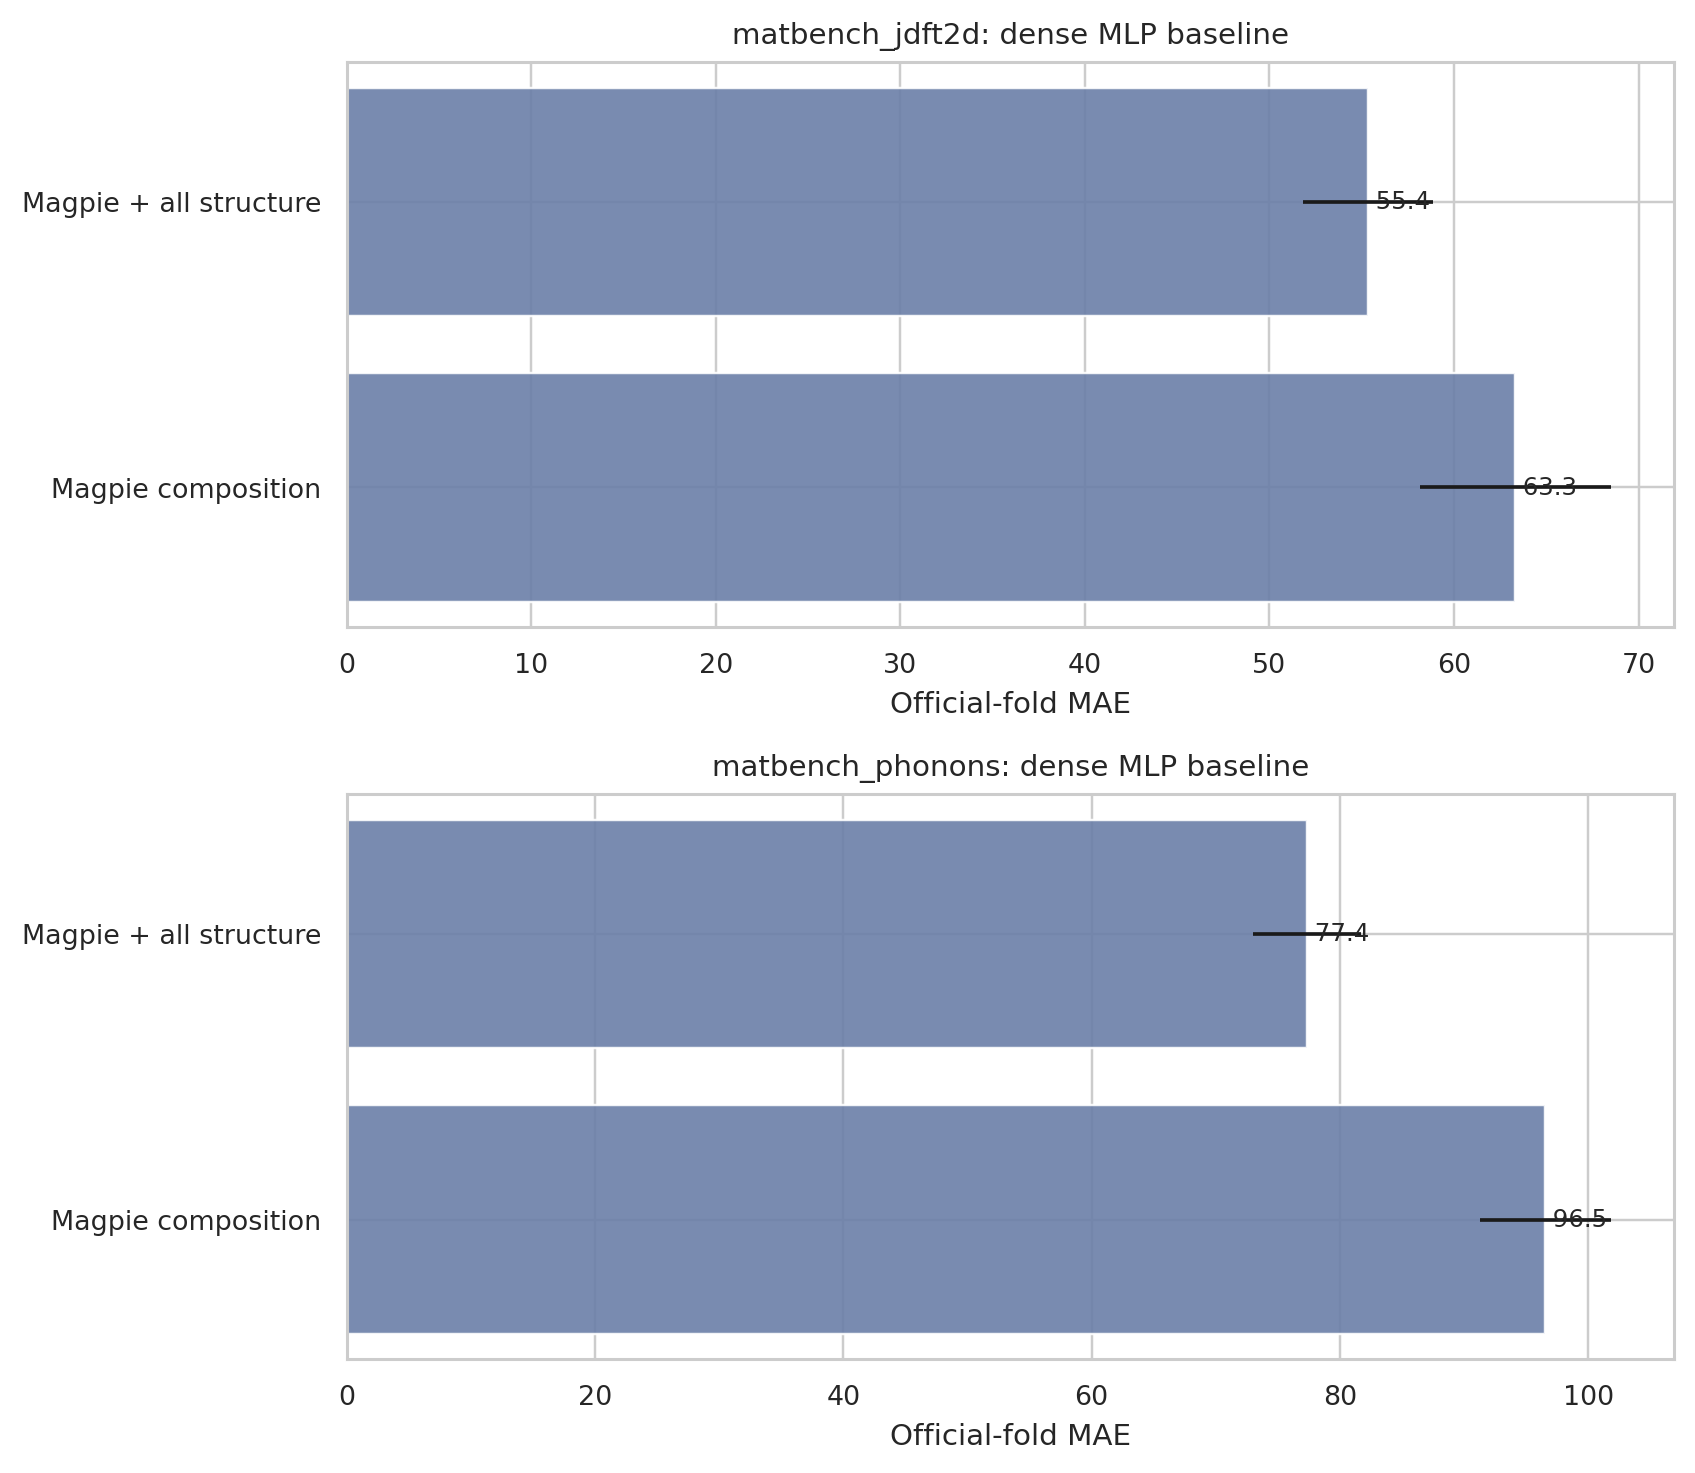

# MLP Baseline Diagnostic Summary

This optional extension tests whether a plain dense neural network can compete with the TabPFN/ExtraTrees workflow on the same descriptor matrices as a model-complexity check.

- `matbench_jdft2d`: best MLP branch is Magpie + all structure, MAE=55.36, R2=0.1797.
- `matbench_phonons`: best MLP branch is Magpie + all structure, MAE=77.35, R2=0.916.

Interpretation guide: if the MLP underperforms TabPFN or tree baselines, dense neural networks are not automatically better on small, high-dimensional tabular materials data.


In [ ]:
from IPython.display import Image, display
import glob

latest_mlp = sorted(glob.glob("results/mlp_baseline_diagnostics/*"))[-1]

display(Image(f"{latest_mlp}/figures/mlp_baseline_mae.png"))
!cat {latest_mlp}/tables/mlp_baseline_summary.md

In [ ]:
!git pull

remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 4 (delta 2), reused 4 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 4.88 KiB | 4.88 MiB/s, done.
From https://github.com/ZuomingWang/matbench-tabpfn
   2f28d78..a2cc6df  main       -> origin/main
Updating 2f28d78..a2cc6df
Fast-forward
 scripts/run_tuned_mlp_baseline_diagnostics.py | 459 ++++++++++++++++++++++++++
 1 file changed, 459 insertions(+)
 create mode 100644 scripts/run_tuned_mlp_baseline_diagnostics.py


In [ ]:
!python scripts/run_tuned_mlp_baseline_diagnostics.py

2026-06-05 23:25:16 INFO     Initialized benchmark 'matbench_v0.1' with 1 tasks: 
['matbench_jdft2d']
2026-06-05 23:25:16 INFO     Loading dataset 'matbench_jdft2d'...
2026-06-05 23:25:16 INFO     Dataset 'matbench_jdft2d loaded.
Building features: matbench_jdft2d | magpie
matbench_jdft2d | magpie | tuned_mlp | fold 0
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings

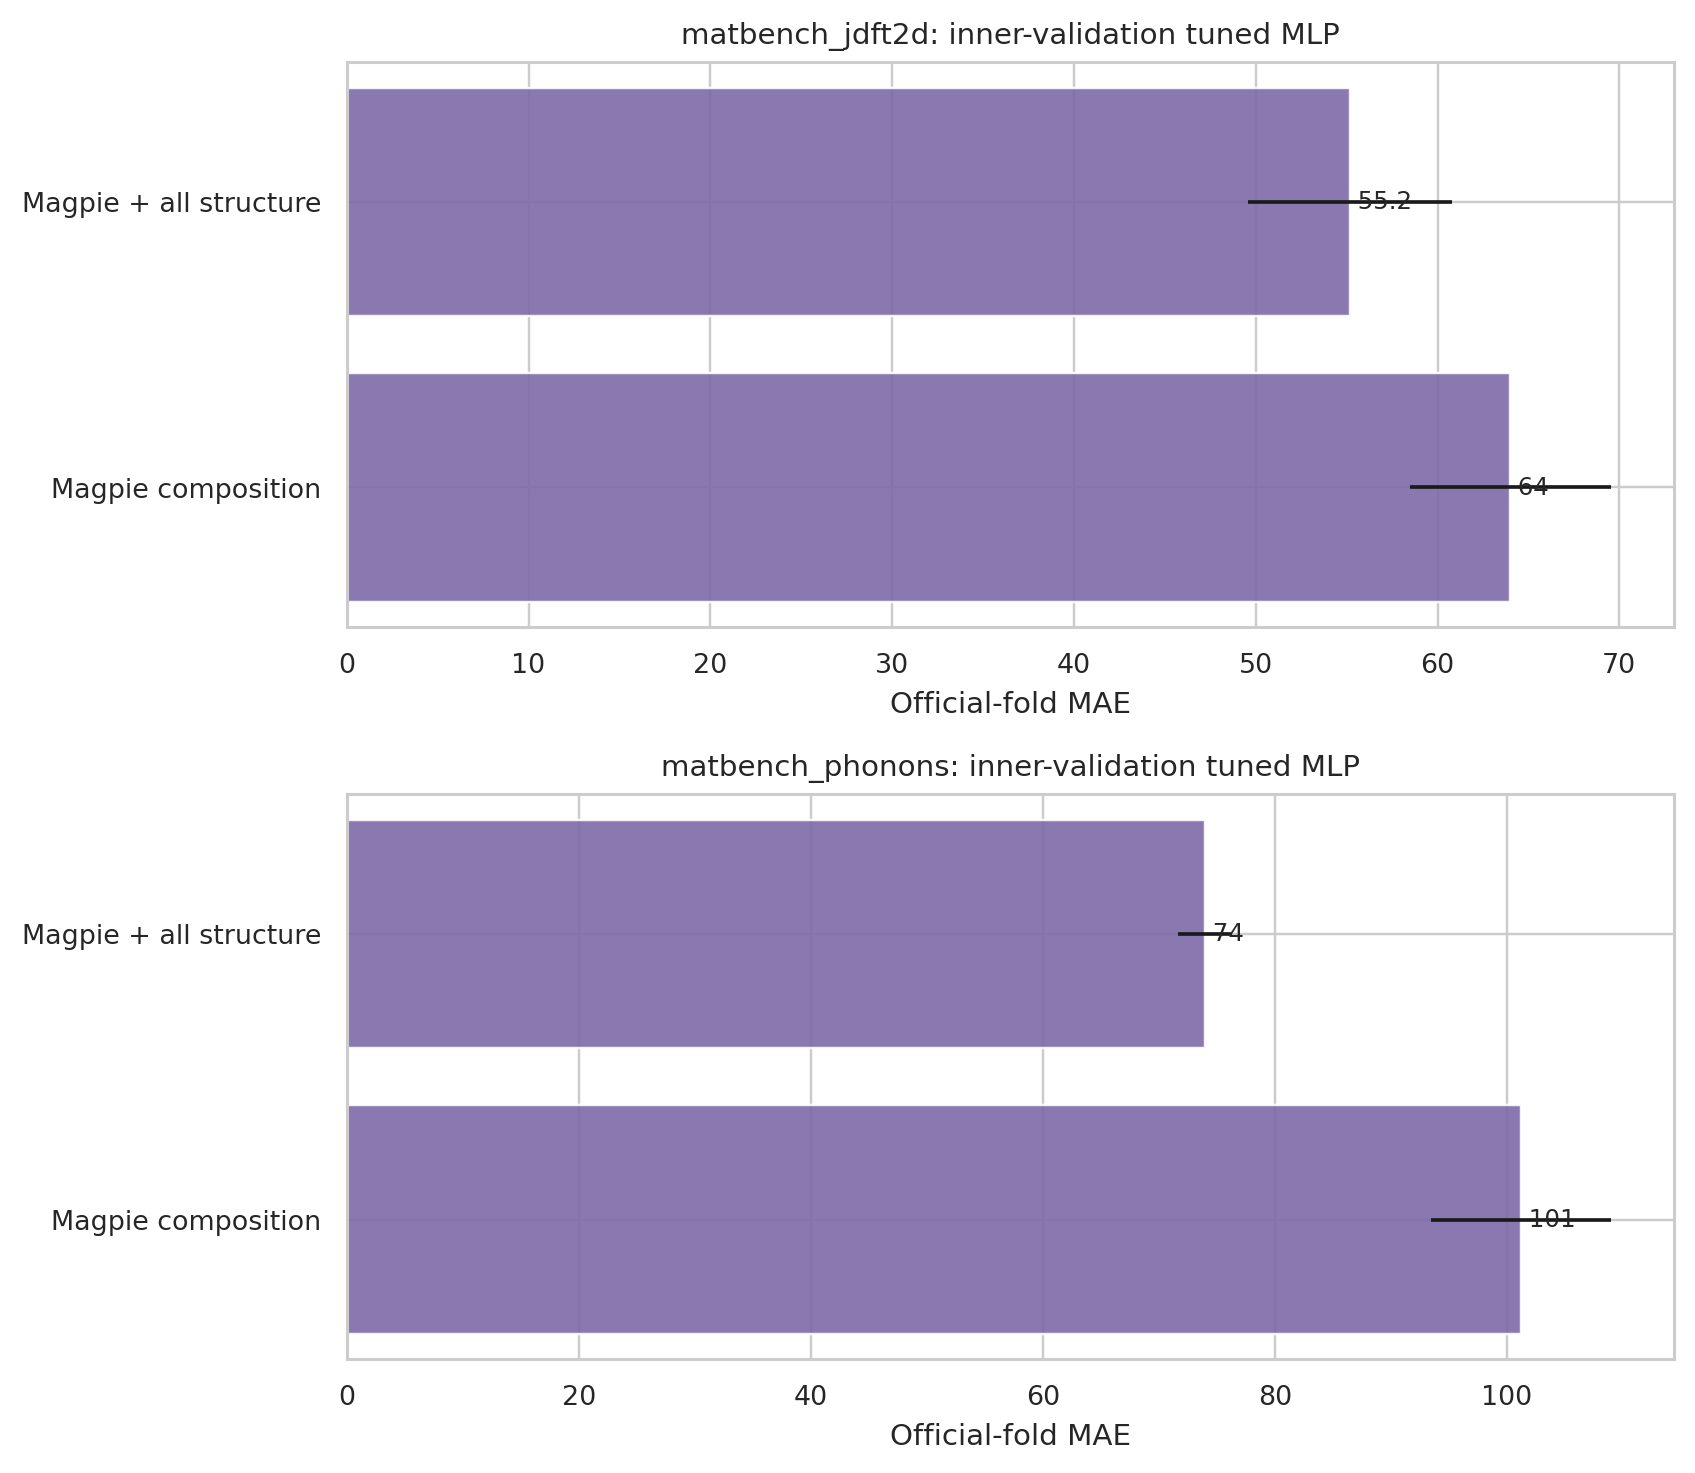

# Tuned MLP Baseline Summary

The MLP hyperparameters were selected by inner validation within each official Matbench training fold. The official test folds were used only for final evaluation.

- `matbench_jdft2d`: best tuned MLP branch is Magpie + all structure, MAE=55.19, R2=0.2006.
- `matbench_phonons`: best tuned MLP branch is Magpie + all structure, MAE=73.99, R2=0.9182.

This model-complexity check compares a tuned dense neural network with TabPFN and tree baselines on the same official folds.


In [ ]:
from IPython.display import Image, display
import glob

latest_tuned_mlp = sorted(glob.glob("results/tuned_mlp_baseline_diagnostics/*"))[-1]

display(Image(f"{latest_tuned_mlp}/figures/tuned_mlp_baseline_mae.png"))
!cat {latest_tuned_mlp}/tables/tuned_mlp_baseline_summary.md